In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
X_train = np.array([[1, 1, 1],
[0, 0, 1],
 [0, 1, 0],
 [1, 0, 1],
 [1, 1, 1],
 [1, 1, 0],
 [0, 0, 0],
 [1, 1, 0],
 [0, 1, 0],
 [0, 1, 0]])

y_train = np.array([1, 1, 0, 0, 1, 1, 0, 1, 0, 0])

In [3]:
X_train[0]

array([1, 1, 1])

In [4]:
def entropy(p): 
    if p == 0 or p == 1: 
        return 0
    else: 
        return -p *np.log2(p) - (1 - p) * np.log2(1 - p)

In [5]:
entropy(0.5)

1.0

In [6]:
def split_indices(X, index_feature): 
    left_indices = []
    right_indices =[]
    for i, x in enumerate(X): 
        if x[index_feature] == 1: 
            left_indices.append(i) 
        else: 
            right_indices.append(i) 
    return left_indices, right_indices

In [7]:
def weighted_entropy(X, y, left_indices, right_indices): 
    w_left = len(left_indices) / len(X) 
    w_right = len(right_indices) / len(X) 
    p_left = sum(y[left_indices]) / len(left_indices) 
    p_right = sum(y[right_indices]) / len(right_indices) 

    weighted_entropy = w_left * entropy(p_left) + w_right * entropy(p_right)
    return weighted_entropy

In [9]:
left_indices, right_indices = split_indices(X_train, 0)
weighted_entropy(X_train, y_train, left_indices, right_indices)

0.7219280948873623

In [10]:
def information_gain(X, y, left_indices, right_indices): 
    p_node = sum(y) / len(y)
    h_node = entropy(p_node) 
    w_entropy = weighted_entropy(X, y, left_indices, right_indices)
    return h_node - w_entropy

In [12]:
for i, feature_name in enumerate(['Ear Shape', 'Face Shape', 'Whiskers']): 
    left_indices, right_indices = split_indices(X_train, i) 
    i_gain = information_gain(X_train, y_train, left_indices, right_indices)
    print(f"Feature: {feature_name}, information gain if we split the root node using this feature: {i_gain:.2f}")

Feature: Ear Shape, information gain if we split the root node using this feature: 0.28
Feature: Face Shape, information gain if we split the root node using this feature: 0.03
Feature: Whiskers, information gain if we split the root node using this feature: 0.12


In [28]:
def compute_entropy(y): 

    entropy = 0

    if len(y) == 0: 
        return 0
        
    entropy = (sum(y[y == 1])) * len(y) 
               
    if entropy == 0 or entropy == 1: 
        return 0 
    else: 
        return -entropy * np.log2(entropy) - (1 - entropy) * np.log2(1 - entropy)

In [25]:
def split_dataset(X, node_indices, feature): 
    left_indices = []
    right_indices = []

    for i in node_indices: 
        if X[i][feature] == 1: 
            left_indices.append(i)
        else: 
            right_indices.append(i)
            
    return left_indices, right_indices

In [22]:
def compute_information_gain(X, y, node_indices, feature): 
    left_indices, right_indices = split_dataset(X, node_indices, feature)

    X_node, y_node = X[node_indices], y[node_indices]
    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]

    information_gain = 0

    node_entropy = compute_entropy(y_node) 
    left_entropy = compute_entropy(y_left) 
    right_entropy = compute_entropy(y_right) 
    w_left = len(y_left) / len(y_train) 
    w_right = len(y_right) / len(y_right) 
    weighted_entropy = w_left * left_entropy + w_right * right_entropy 
    information_gain = node_entropy - weighted_entropy 

    return information_gain

In [18]:
def get_best_split(X, y, node_indices): 
    num_feature = X.shape[1]

    best_feature = -1
    max_info_gain = 0
    for feature in range(num_feature): 
        info_gain = compute_information_gain(X, y, node_indices, feature) 
        if info_gain > max_info_gain: 
            max_info_gain = info_gain 
            best_feature = feature 
            
    return best_feature

In [32]:
def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth, tree): 
    if current_depth == max_depth: 
        formatting = " "*current_depth + "-"* current_depth 
        print(formatting, "%s leaf node with indices" % branch_name, node_indices) 
        return 

    best_feature = get_best_split(X, y, node_indices) 

    formatting = "-"* current_depth 
    print("%s Depth %d, %s: Split on feature: %d" % (formatting, current_depth, branch_name, best_feature))
    tree.append((left_indices, right_indices, best_feature))

    build_tree_recursive(X, y, left_indices, "Left", max_depth, current_depth + 1, tree)
    build_tree_recursive(X, y, right_indices, "Right", max_depth, current_depth + 1, tree)

In [33]:
tree = []
build_tree_recursive(X_train, y_train, [0,1,2,3,4,5,6,7,8,9], "Root", max_depth=1, current_depth=0, tree = tree)

 Depth 0, Root: Split on feature: -1
 - Left leaf node with indices [0, 1, 3, 4]
 - Right leaf node with indices [2, 5, 6, 7, 8, 9]


/var/folders/47/c_w9jlv53lgdn8fb4nhx6smr0000gn/T/ipykernel_29053/639821117.py:13: RuntimeWarning: invalid value encountered in log2
  return -entropy * np.log2(entropy) - (1 - entropy) * np.log2(1 - entropy)


## Tree Ensembles

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score 
from xgboost import XGBClassifier 
import matplotlib.pyplot as plt 

RANDOM_STATE = 55

In [3]:
df = pd.read_csv("data/heart.csv") 

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
cat_variables = [
    "Sex", 
    "ChestPainType", 
    "RestingECG", 
    "ExerciseAngina", 
    "ST_Slope"
]

As a reminder, one-hot encoding aims to trainsform a categorical variable with `n` outputs into `n` binary variables 

Pandas has a built-in method to one-hot encode variable, it is the function `pd.get_dummies`. There are several arguments to this function, but here we will use only a few. They are: 
* data: DataFrame to be used
* prefix: a list with prefixes, so we know which value we are dealing with
* columns: the list of columns that will be one-hot encoded. "prefix" and "columns" must have the same length

In [6]:
df = pd.get_dummies(data = df, 
                    prefix = cat_variables, 
                    columns = cat_variables)

In [7]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


* The target is `HeartDisease`. 
* All other variables are features that can potentially be used to predict the target, `HeartDisease`

In [8]:
features = [x for x in df.columns if x not in 'HeartDisease']

In [10]:
print(len(features))

20


## Splitting the Dataset

In [14]:
X_train, X_val, y_train, y_val = train_test_split(df[features], 
                                                  df['HeartDisease'], 
                                                  train_size = 0.8, 
                                                  random_state = RANDOM_STATE)

In [15]:
print(f"train samples: {len(X_train)}") 
print(f"validation samples: {len(X_val)}") 
print(f"target proportion: {sum(y_train)/len(y_train):.4f}") 

train samples: 734
validation samples: 184
target proportion: 0.5518


## Building the Models 

### 4.1 Decision Tree

In [16]:
min_samples_split_list = [2, 10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1, 2, 3, 4, 8, 16, 32, 64, None]

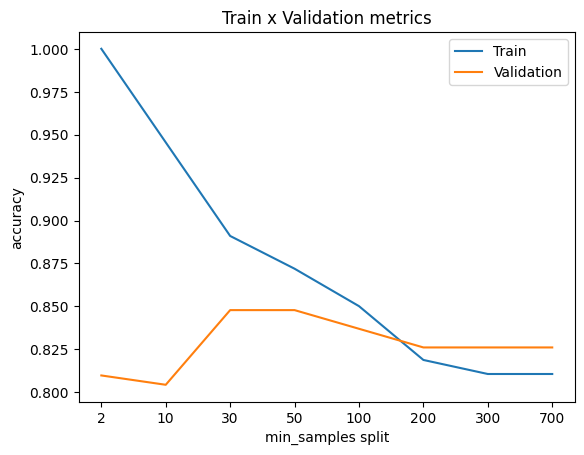

In [17]:
accuracy_list_train = []
accuracy_list_val = []

for min_sample_list in min_samples_split_list: 
    model = DecisionTreeClassifier(min_samples_split = min_sample_list, 
                                   random_state = RANDOM_STATE).fit(X_train, y_train) 
    predictions_train = model.predict(X_train) 
    predictions_val = model.predict(X_val) 
    accuracy_train = accuracy_score(predictions_train, y_train) 
    accuracy_val = accuracy_score(predictions_val, y_val) 
    accuracy_list_train.append(accuracy_train) 
    accuracy_list_val.append(accuracy_val) 

plt.title("Train x Validation metrics") 
plt.xlabel("min_samples split") 
plt.ylabel("accuracy") 
plt.xticks(ticks = range(len(min_samples_split_list)), labels = min_samples_split_list)
plt.plot(accuracy_list_train) 
plt.plot(accuracy_list_val) 
plt.legend(["Train", "Validation"]) 

Note how increasing the the number of `min_samples_split` reduces overfitting. 
* Increasing `min_samples_split` from 10 to 30, and from 30 to 50, even though it does not improve the validation accuracy, it brings the training accuracy closer to it, showing a reduction in overfitting.


5


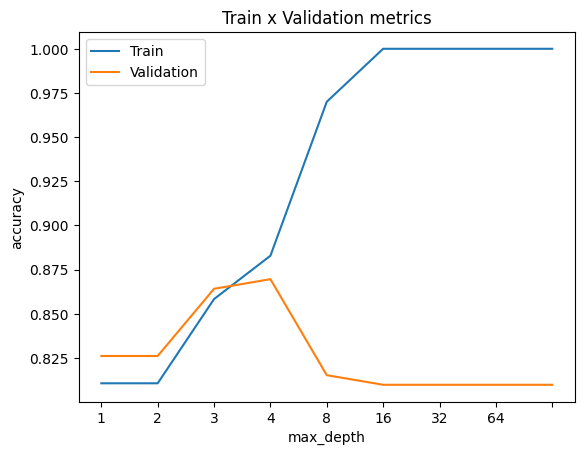

In [24]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list: 
    model = DecisionTreeClassifier(max_depth = max_depth, 
                               random_state = RANDOM_STATE).fit(X_train, y_train) 
    predictions_train = model.predict(X_train) 
    predictions_val = model.predict(X_val) 
    accuracy_train = accuracy_score(predictions_train, y_train) 
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train) 
    accuracy_list_val.append(accuracy_val) 

print(np.argmax(accuracy_list_train))
plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

We can see that in general, reducing `max_depth` can help to reduce overfitting.
- Reducing `max_depth` from 8 to 4 increases validation accuracy closer to training accuracy, while significantly reducing training accuracy.
- The validation accuracy reaches the highest at tree_depth=4. 
- When the `max_depth` is smaller than 3, both training and validation accuracy decreases.  The tree cannot make enough splits to distinguish positives from negatives (the model is underfitting the training set). 
- When the `max_depth` is too high ( >= 5), validation accuracy decreases while training accuracy increases, indicating that the model is overfitting to the training set.

So we can choose the best values for these two hyper-parameters for our model to be:
- `max_depth = 4`
- `min_samples_split = 50` 

In [26]:
decision_tree_model = DecisionTreeClassifier(min_samples_split = 50, 
                                            max_depth = 3, 
                                            random_state = RANDOM_STATE).fit(X_train, y_train)

In [27]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_train),y_train):.4f}")
print(f"Metrics validation:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.8583
Metrics validation:
	Accuracy score: 0.8641


## Random Forest 

Now let's try the Random Forest Algorithm also, using Scikit-learn implementation. 
* All of the hyperparameters found in the decision tree model will also exist in this algorithm, since a random forest is an ensemble of many Decision Trees.
* One additional hyperparameter for Random Forest is called `n_estimators` which is the number of Decision Trees that make up the Random Forest

Remember that for a Random Forest, we randomly choose a subset of the features AND randomly choose a subset of the training examples to train each individual tree 
* Follwoing the lectures, if n is the number of features, we will randomly select $\sqrt{n}$ of these features to train each individual tree.
* Note that you can modify this by setting the `max_features` parameter
You can also speed up your training jobs with another parameter, `n_jobs`.
* Since the fitting of each tree is independent of each other, it is possible fit more than one tree in parallel.
* so setting `n_jobs` higher will increase how many CPU cores it will use. Note that the numbers very close to the maximum cores of your maximum cores of you CPU may impact on the overall performance of your PC and even lead to freeze.
* Changing this parameter does not impact on the final result but can reduce the training time

In [28]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, then it is the actual quantity of samples,
                                             ## If it is a float, then it is the percentage of the dataset
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10,50,100,500]

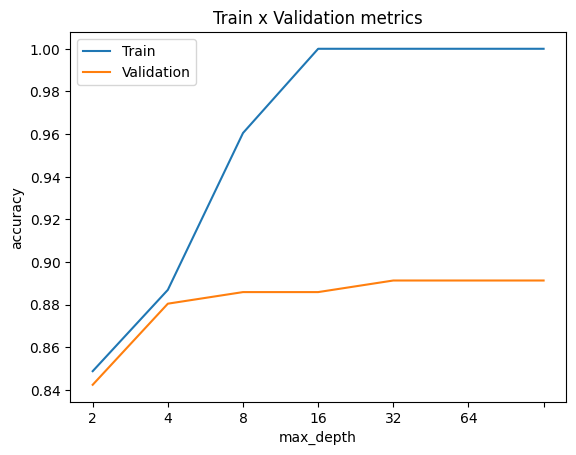

In [29]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth = max_depth,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_val = model.predict(X_val) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

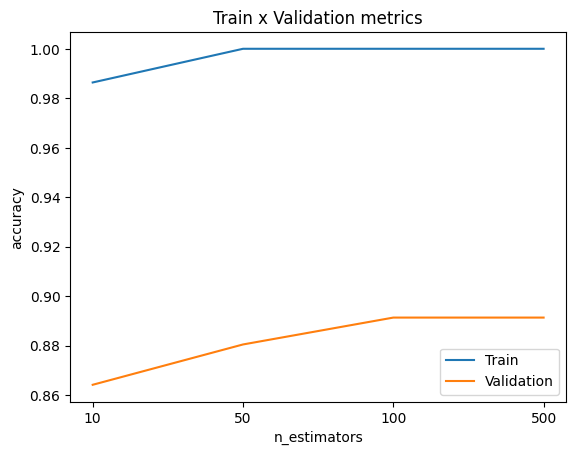

In [30]:
accuracy_list_train = []
accuracy_list_val = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators = n_estimators,
                                   random_state = RANDOM_STATE).fit(X_train,y_train) 
    predictions_train = model.predict(X_train) ## The predicted values for the train dataset
    predictions_val = model.predict(X_val) ## The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(n_estimators_list )),labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train','Validation'])

In [31]:
random_forest_model = RandomForestClassifier(n_estimators = 100,
                                             max_depth = 16, 
                                             min_samples_split = 10).fit(X_train,y_train)

In [32]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9305
Metrics test:
	Accuracy score: 0.8804


## 4.3 XGBoost

Next is the Gradient Boosting model, called XGBoost. The boosting methods train several trees, but instead of them being uncorrelated to each other, now the trees are fit one after the other in order to minimize the error. 

The model has the same parameters as a decision tree, plus the learning rate.
- The learning rate is the size of the step on the Gradient Descent method that the XGBoost uses internally to minimize the error on each train step.

One interesting thing about the XGBoost is that during fitting, it can take in an evaluation dataset of the form `(X_val,y_val)`.
- On each iteration, it measures the cost (or evaluation metric) on the evaluation datasets.
- Once the cost (or metric) stops decreasing for a number of rounds (called early_stopping_rounds), the training will stop. 
- More iterations lead to more estimators, and more estimators can result in overfitting.  
- By stopping once the validation metric no longer improves, we can limit the number of estimators created, and reduce overfitting.

First, let's define a subset of our training set (we should not use the test set here).

In [33]:
n = int(len(X_train) * 0.8)

In [34]:
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n],X_train[n:], y_train[:n], y_train[n:]

Note some of the `.fit()` parameters: 
* `eval_set = [(X_train_eval,y_train_eval)]`: Here we must pass a list to the eval set, because you can have several different tuples of eval set
- `early_stopping_rounds`: This parameter helps to stop the model training if its evaluation metric is no longer improving on the validation set. It's set to 10.
  - The model keeps track of the round with the best performance (lowest evaluation metric).  For example, let's say round 16 has the lowest evaluation metric so far.
  - Each successive round's evaluation metric is compared to the best metric.  If the model goes 10 rounds where none have a better metric than the best one, then the model stops training.
  - The model is returned at its last state when training terminated, not its state during the best round.  For example, if the model stops at round 26, but the best round was 16, the model's training state at round 26 is returned, not round 16.
  - Note that this is different from returning the model's "best" state (from when the evaluation metric was the lowest).

In [35]:
xgb_model = XGBClassifier(n_estimators = 500, 
                          learning_rate = 0.1, 
                          verbosity = 1, 
                          random_state = RANDOM_STATE, 
                          early_stopping_rounds = 10) 
xgb_model.fit(X_train_fit, y_train_fit, eval_set = [(X_train_eval, y_train_eval)])

[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

Even though we initialized the model to allow up to 500 estimators, the algorithm only fit 26 estimators 

In [36]:
xgb_model.best_iteration

17

In [37]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\nMetrics test:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_val),y_val):.4f}")

Metrics train:
	Accuracy score: 0.9319
Metrics test:
	Accuracy score: 0.8533


## Decision Trees

In [38]:
import numpy as np 
import matplotlib.pyplot as plt 

## 2- Problem Statement 

Suppose you are starting a company that grows and sells wild mushrooms. 
- Since not all mushrooms are edible, you'd like to be able to tell whether a given mushroom is edible or poisonous based on it's physical attributes
- You have some existing data that you can use for this task. 

Can you use the data to help you identify which mushrooms can be sold safely? 

Note: The dataset used is for illustrative purposes only. It is not meant to be a guide on identifying edible mushrooms.

In [39]:
X_train = np.array([[1,1,1],[1,0,1],[1,0,0],[1,0,0],[1,1,1],[0,1,1],[0,0,0],[1,0,1],[0,1,0],[1,0,0]])
y_train = np.array([1,1,0,0,1,0,0,1,1,0])

In [40]:
print("First few elements of X_train:\n", X_train[:5]) 
print("Type of X_train:", type(X_train))

First few elements of X_train:
 [[1 1 1]
 [1 0 1]
 [1 0 0]
 [1 0 0]
 [1 1 1]]
Type of X_train: <class 'numpy.ndarray'>


In [42]:
print("The shape of X_train is:", X_train.shape) 
print("The shape of y_train is:", y_train.shape) 
print("Number of training examples (m):", len(X_train)) 

The shape of X_train is: (10, 3)
The shape of y_train is: (10,)
Number of training examples (m): 10


### 4.1 Compute entropy

In [44]:
def compute_entropy(y): 

    if len(y) == 0: 
        return 0 
    entropy = 0 
    p1 = len(y[y == 1]) / len(y) 

    if p1 != 0 or p1 != 1: 
        entropy = -p1 * np.log2(p1) - (1 - p1) * np.log2(1 - p1) 

    return entropy

In [45]:
print("Entropy at root node:", compute_entropy(y_train))

Entropy at root node: 1.0


## 4.2 Split dataset

In [48]:
def split_dataset(X, node_indices, feature): 
    left_indices = []
    right_indices = []
    for index in node_indices: 
        if X[index][feature] == 1: 
            left_indices.append(index)
        else: 
            right_indices.append(index)

    return left_indices, right_indices

In [49]:
# Case 1

root_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Feel free to play around with these variables
# The dataset only has three features, so this value can be 0 (Brown Cap), 1 (Tapering Stalk Shape) or 2 (Solitary)
feature = 0

left_indices, right_indices = split_dataset(X_train, root_indices, feature)

print("CASE 1:")
print("Left indices: ", left_indices)
print("Right indices: ", right_indices)

CASE 1:
Left indices:  [0, 1, 2, 3, 4, 7, 9]
Right indices:  [5, 6, 8]


### 4.3 Calculate Information Gain 

In [52]:
def compute_information_gain(X, y, node_indices, feature): 
    left_indices, right_indices = split_dataset(X, node_indices, feature)

    X_node, y_node = X[node_indices], y[node_indices]
    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]

    information_gain = 0 
    root_entropy = compute_entropy(y_node) 
    left_subbranch_entropy = compute_entropy(y_left) 
    right_subbranch_entropy = compute_entropy(y_right) 
    w_left = len(left_indices) / len(y_node) 
    w_right = len(right_indices) / len(y_node) 

    information_gain = root_entropy - (w_left * left_subbranch_entropy + w_right * right_subbranch_entropy) 

    return information_gain

In [53]:
info_gain0 = compute_information_gain(X_train, y_train, root_indices, feature=0)
print("Information Gain from splitting the root on brown cap: ", info_gain0)

info_gain1 = compute_information_gain(X_train, y_train, root_indices, feature=1)
print("Information Gain from splitting the root on tapering stalk shape: ", info_gain1)

info_gain2 = compute_information_gain(X_train, y_train, root_indices, feature=2)
print("Information Gain from splitting the root on solitary: ", info_gain2)


Information Gain from splitting the root on brown cap:  0.034851554559677034
Information Gain from splitting the root on tapering stalk shape:  0.12451124978365313
Information Gain from splitting the root on solitary:  0.2780719051126377


In [82]:
def get_best_split(X, y, node_indices): 
    num_feature = X.shape[1]
    info_gain = 0
    best_feature = -1

    for feature in range(num_feature):
        information_gain = float(compute_information_gain(X, y, node_indices, feature)) 
        if information_gain > info_gain: 
            info_gain = information_gain 
            best_feature = feature 
            # print(best_feature)

    return best_feature

In [55]:
best_feature = get_best_split(X_train, y_train, root_indices)
print("Best feature to split on: %d" % best_feature)

Best feature to split on: 2


In [83]:
tree = []

def build_tree_recursive(X, y, node_indices, branch_name, max_depth, current_depth): 
    if current_depth == max_depth: 
        formatting = " "* current_depth + "-"* current_depth 
        print(formatting, "%s leaf node with indices" % branch_name, node_indices) 
        return 

    best_feature = get_best_split(X, y, node_indices)
    print("Best feature returned:", best_feature)  # ← Add this
    formatting = "-"*current_depth
    print("%s Depth %d, %s: Split on feature: %d" % (formatting, current_depth, branch_name, best_feature))

    left_indices, rigth_indices = split_dataset(X, node_indices, best_feature) 
    tree.append((left_indices, right_indices, best_feature))

    build_tree_recursive(X, y, left_indices, "Left", max_depth, current_depth + 1)
    build_tree_recursive(X, y, right_indices, "Right", max_depth, current_depth + 1)

In [81]:
build_tree_recursive(X_train, y_train, root_indices, "Root", max_depth=2, current_depth=0)

Best feature returned: 2
 Depth 0, Root: Split on feature: 2
Best feature returned: 2
- Depth 1, Left: Split on feature: 2
  -- Left leaf node with indices [0, 1, 4, 5, 7]
  -- Right leaf node with indices [5, 6, 8]
Best feature returned: 0
- Depth 1, Right: Split on feature: 0
  -- Left leaf node with indices []
  -- Right leaf node with indices [5, 6, 8]


/var/folders/47/c_w9jlv53lgdn8fb4nhx6smr0000gn/T/ipykernel_29602/3508508964.py:9: RuntimeWarning: divide by zero encountered in log2
  entropy = -p1 * np.log2(p1) - (1 - p1) * np.log2(1 - p1)
/var/folders/47/c_w9jlv53lgdn8fb4nhx6smr0000gn/T/ipykernel_29602/3508508964.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  entropy = -p1 * np.log2(p1) - (1 - p1) * np.log2(1 - p1)
